# Phase 1: Classical Baseline Mastery 


## Parameters 

| Parameter | Value |
|-----------|-------|
| PDE | $u_t + u u_x - \frac{0.01}{\pi} u_{xx} = 0$ |
| Architecture | 8 hidden × 20 neurons, tanh, **3 021 params** |
| $N_u$ | 100 |
| $N_f$ | 10 000 (LHS) |
| Optimizer | **L-BFGS-B** (scipy, Raissi's exact) |
| Seed | 42 |

## 1. Install and Verify Dependencies

In [2]:
import torch
import numpy as np
import scipy
from scipy.optimize import minimize
import matplotlib
import json
import time
import os

print(f"[OK] PyTorch version:  {torch.__version__}")
print(f"[OK] NumPy version:    {np.__version__}")
print(f"[OK] SciPy version:    {scipy.__version__}")
print(f"[OK] CUDA available:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"     GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"     (CPU is sufficient for Phase 1; the classical PINN is small)")

[OK] PyTorch version:  2.13.0+cpu
[OK] NumPy version:    2.3.5
[OK] SciPy version:    1.16.3
[OK] CUDA available:   False
     (CPU is sufficient for Phase 1; the classical PINN is small)


## 2. Imports and Configuration

In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
from scipy.optimize import minimize
from scipy.special import logsumexp
import json, time, os

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Device
device = torch.device('cpu')
print(f"[OK] Using device: {device}")

# float32 gradient noise makes L-BFGS-B declare premature convergence.
# float64 (machine epsilon ~2.2e-16) allows convergence to loss ~1e-8.
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)
print(f"[OK] Using dtype: {DTYPE} (double precision for convergence)")

# Project directories
# Ensure PROJECT_ROOT is defined to avoid NameError when running locally.
PROJECT_ROOT = os.getcwd()  # fallback to current working directory
DIRS = {
    'root':    PROJECT_ROOT,
    'code':    os.path.join(PROJECT_ROOT, 'code'),
    'data':    os.path.join(PROJECT_ROOT, 'data'),
    'results': os.path.join(PROJECT_ROOT, 'results'),
    'figures': os.path.join(PROJECT_ROOT, 'figures'),
    'models':  os.path.join(PROJECT_ROOT, 'models'),
    'logs':    os.path.join(PROJECT_ROOT, 'logs'),
}
for name, path in DIRS.items():
    os.makedirs(path, exist_ok=True)
print(f"[OK] Project directories ready under {PROJECT_ROOT}")

[OK] Using device: cpu
[OK] Using dtype: torch.float64 (double precision for convergence)
[OK] Project directories ready under /home/roland/WISER


## 3. Burgers' Equation Setup 

$$u_t + u \, u_x - \frac{0.01}{\pi} \, u_{xx} = 0, \quad x \in [-1, 1], \; t \in [0, 1]$$

**IC:** $u(0, x) = -\sin(\pi x)$  
**BC:** $u(t, \pm 1) = 0$

In [4]:
# Burgers' equation parameters (matches Raissi 2017 exactly)
NU = 0.01 / np.pi
X_MIN, X_MAX = -1.0, 1.0
T_MIN, T_MAX = 0.0, 1.0

N_U = 100
N_F = 10000

# Sample initial condition points
n_ic = N_U // 2
x_ic = np.random.uniform(X_MIN, X_MAX, n_ic)
t_ic = np.zeros(n_ic)
u_ic = -np.sin(np.pi * x_ic)

# Sample boundary condition points
n_bc = N_U - n_ic
t_bc = np.random.uniform(T_MIN, T_MAX, n_bc)
x_bc = np.where(np.random.rand(n_bc) < 0.5, X_MIN, X_MAX)
u_bc = np.zeros(n_bc)

x_u_np = np.concatenate([x_ic, x_bc]).reshape(-1, 1)
t_u_np = np.concatenate([t_ic, t_bc]).reshape(-1, 1)
u_u_np = np.concatenate([u_ic, u_bc]).reshape(-1, 1)

# FIX #2: Latin Hypercube Sampling for collocation points
lhs_sampler = qmc.LatinHypercube(d=2, scramble=True, strength=1, seed=SEED)
lhs_sample = lhs_sampler.random(n=N_F)
x_f_np = (X_MIN + (X_MAX - X_MIN) * lhs_sample[:, 0]).reshape(-1, 1)
t_f_np = (T_MIN + (T_MAX - T_MIN) * lhs_sample[:, 1]).reshape(-1, 1)

x_u = torch.tensor(x_u_np, dtype=DTYPE, device=device)
t_u = torch.tensor(t_u_np, dtype=DTYPE, device=device)
u_u = torch.tensor(u_u_np, dtype=DTYPE, device=device)
x_f = torch.tensor(x_f_np, dtype=DTYPE, device=device)
t_f = torch.tensor(t_f_np, dtype=DTYPE, device=device)

print(f"[OK] Data points (initial + boundary): {x_u.shape[0]}")
print(f"[OK] Collocation points (PDE residual, LHS): {x_f.shape[0]}")
print(f"[OK] Viscosity nu = {NU:.6f}")
print(f"[OK] Collocation sampling: Latin Hypercube (scipy.stats.qmc.LatinHypercube, seed={SEED})")

[OK] Data points (initial + boundary): 100
[OK] Collocation points (PDE residual, LHS): 10000
[OK] Viscosity nu = 0.003183
[OK] Collocation sampling: Latin Hypercube (scipy.stats.qmc.LatinHypercube, seed=42)


## 4. Analytical Reference Solution : Cole–Hopf (float64)

$$u(x, t) = \frac{\int_{-\infty}^{\infty} \frac{x-y}{t} \, e^{-F(y;x,t)} \, dy}{\int_{-\infty}^{\infty} e^{-F(y;x,t)} \, dy}$$

where $F(y; x, t) = \frac{\cos(\pi y)}{2\pi\nu} + \frac{(x-y)^2}{4\nu t}$.

Generating analytical Cole-Hopf reference (float64)...
[OK] Analytical reference generated: shape (256, 256), dtype=float64
     Time: 6.4 sec
     Value range: [-0.999981, 0.999981]

Verification:
  u(0, x=0.5) = -1.00000000  (should be -1.0)
  u(t=0.5, x=0) = -2.96e-16  (should be ~0)
  u(t=0.5, x=1) = -2.67e-17  (should be ~0)


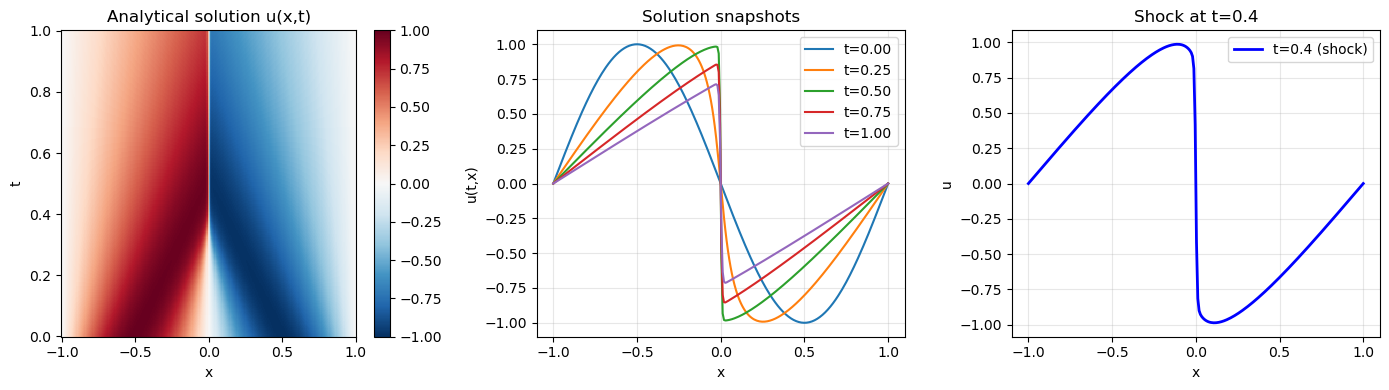

[OK] Reference visualised


In [5]:
def burgers_analytical(x_arr, t_arr, nu=NU, n_quad=4000):
    """Analytical solution of viscous Burgers via Cole-Hopf transformation.
    
    u_t + u u_x = nu u_xx,  u(0,x) = -sin(pi x), u(t, +/-1) = 0
    
    Solution (weighted-average form, numerically stable):
        u(x,t) = sum_k [factor_k * w_k] / sum_k [w_k]
    where:
        factor_k = (x - y_k) / t
        w_k = exp(-F_k - max_j(-F_j))
        F(y; x, t) = cos(pi y)/(2 pi nu) + (x-y)^2 / (4 nu t)
    """
    x_arr = np.atleast_1d(np.asarray(x_arr, dtype=np.float64))
    t_arr = np.atleast_1d(np.asarray(t_arr, dtype=np.float64))
    
    Nt, Nx = len(t_arr), len(x_arr)
    u = np.zeros((Nt, Nx), dtype=np.float64)
    
    L = 3.0
    y = np.linspace(-L, L, n_quad)
    cos_term = np.cos(np.pi * y) / (2.0 * np.pi * nu)
    
    for i, ti in enumerate(t_arr):
        if ti < 1e-12:
            u[i, :] = -np.sin(np.pi * x_arr)
            continue
        
        x_col = x_arr.reshape(-1, 1)
        y_row = y.reshape(1, -1)
        
        gaussian_term = (x_col - y_row) ** 2 / (4.0 * nu * ti)
        F = cos_term.reshape(1, -1) + gaussian_term
        log_integrand = -F
        
        max_log = np.max(log_integrand, axis=1, keepdims=True)
        weights = np.exp(log_integrand - max_log)
        
        factor = (x_col - y_row) / ti
        
        u_num = np.sum(factor * weights, axis=1)
        u_den = np.sum(weights, axis=1)
        
        u[i, :] = np.where(u_den > 0, u_num / u_den, 0.0)
    
    return u


# Generate the analytical reference
print("Generating analytical Cole-Hopf reference (float64)...")
t0 = time.time()
N_REF_X, N_REF_T = 256, 256
x_ref_grid = np.linspace(X_MIN, X_MAX, N_REF_X)
t_ref_grid = np.linspace(T_MIN, T_MAX, N_REF_T)
U_ref = burgers_analytical(x_ref_grid, t_ref_grid)
t1 = time.time()
print(f"[OK] Analytical reference generated: shape {U_ref.shape}, dtype={U_ref.dtype}")
print(f"     Time: {t1-t0:.1f} sec")
print(f"     Value range: [{U_ref.min():.6f}, {U_ref.max():.6f}]")

print("\nVerification:")
print(f"  u(0, x=0.5) = {burgers_analytical(np.array([0.5]), np.array([0.0]))[0,0]:.8f}  (should be -1.0)")
print(f"  u(t=0.5, x=0) = {burgers_analytical(np.array([0.0]), np.array([0.5]))[0,0]:.2e}  (should be ~0)")
print(f"  u(t=0.5, x=1) = {burgers_analytical(np.array([1.0]), np.array([0.5]))[0,0]:.2e}  (should be ~0)")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ax = axes[0]
im = ax.pcolormesh(x_ref_grid, t_ref_grid, U_ref, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('Analytical solution u(x,t)')
plt.colorbar(im, ax=ax)
ax = axes[1]
for t_snap in [0.0, 0.25, 0.5, 0.75, 1.0]:
    idx = np.argmin(np.abs(t_ref_grid - t_snap))
    ax.plot(x_ref_grid, U_ref[idx, :], linewidth=1.5, label=f't={t_snap:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('u(t,x)'); ax.set_title('Solution snapshots')
ax.legend(); ax.grid(True, alpha=0.3)
ax = axes[2]
idx_t04 = np.argmin(np.abs(t_ref_grid - 0.4))
ax.plot(x_ref_grid, U_ref[idx_t04, :], 'b-', linewidth=2, label=f't=0.4 (shock)')
ax.set_xlabel('x'); ax.set_ylabel('u'); ax.set_title('Shock at t=0.4')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_analytical_reference.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Reference visualised")

## 5. Classical PINN Model 

8 hidden layers × 20 neurons, tanh, 3,021 parameters. Glorot uniform init.

In [6]:
class ClassicalPINN(nn.Module):
    """Classical Physics-Informed Neural Network for Burgers equation.
    Architecture: 8 hidden layers x 20 neurons, tanh, 3021 params.
    """
    def __init__(self, n_hidden_layers=8, width=20):
        super().__init__()
        layers = []
        layers.append(nn.Linear(2, width))
        layers.append(nn.Tanh())
        for _ in range(n_hidden_layers - 1):
            layers.append(nn.Linear(width, width))
            layers.append(nn.Tanh())
        layers.append(nn.Linear(width, 1))
        self.net = nn.Sequential(*layers)

        # FIX #4: xavier_uniform_ (Glorot uniform) — matches Raissi's TensorFlow code
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

model = ClassicalPINN(n_hidden_layers=8, width=20).to(device)
model = model.double()  # V6: convert to float64 for precision
n_params = sum(p.numel() for p in model.parameters())
print(f"[OK] Classical PINN created")
print(f"     Hidden layers: 8 (each 20 neurons, tanh)")
print(f"     Total parameters: {n_params}")
assert n_params == 3021, f"Parameter mismatch: expected 3021, got {n_params}"
print(f"     [OK] Parameter count matches Raissi (2017)")
print(f"     [OK] Init: xavier_uniform_ (Glorot uniform, matches Raissi)")

with torch.no_grad():
    u_test = model(x_u[:5], t_u[:5])
print(f"[OK] Forward pass test: output shape = {u_test.shape}")

[OK] Classical PINN created
     Hidden layers: 8 (each 20 neurons, tanh)
     Total parameters: 3021
     [OK] Parameter count matches Raissi (2017)
     [OK] Init: xavier_uniform_ (Glorot uniform, matches Raissi)
[OK] Forward pass test: output shape = torch.Size([5, 1])


## 6. PINN Loss Function

$$\mathcal{L} = \mathcal{L}_u + \mathcal{L}_f$$

- **Data loss** $\mathcal{L}_u$: MSE at initial/boundary data points.
- **Physics loss** $\mathcal{L}_f$: MSE of PDE residual $f = u_t + u \, u_x - \nu \, u_{xx}$ via autograd.

In [7]:
def compute_loss(model, x_u, t_u, u_u, x_f, t_f, nu=NU):
    """Compute PINN loss = MSE_u + MSE_f."""
    u_pred = model(x_u, t_u)
    mse_u = torch.mean((u_pred - u_u) ** 2)

    x_f_grad = x_f.detach().clone().requires_grad_(True)
    t_f_grad = t_f.detach().clone().requires_grad_(True)
    u_f = model(x_f_grad, t_f_grad)

    u_x = torch.autograd.grad(u_f, x_f_grad, torch.ones_like(u_f), create_graph=True, retain_graph=True)[0]
    u_t = torch.autograd.grad(u_f, t_f_grad, torch.ones_like(u_f), create_graph=True, retain_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x_f_grad, torch.ones_like(u_x), create_graph=True, retain_graph=True)[0]

    f = u_t + u_f * u_x - nu * u_xx
    mse_f = torch.mean(f ** 2)

    return mse_u + mse_f, mse_u, mse_f

with torch.enable_grad():
    loss, l_u, l_f = compute_loss(model, x_u, t_u, u_u, x_f, t_f)
print(f"[OK] Loss test (untrained): total={loss.item():.6f}, u={l_u.item():.6f}, f={l_f.item():.6f}")

[OK] Loss test (untrained): total=0.600266, u=0.567820, f=0.032446


## 7. Training : scipy L-BFGS-B 

In [8]:
# ====================================================================
# FIX #3: scipy L-BFGS-B with Raissi's exact parameters
# ====================================================================
# 
# Raissi's original code (TensorFlow):
#   tf.contrib.opt.ScipyOptimizerInterface(loss, method='L-BFGS-B',
#       options={'maxiter': 50000, 'maxfun': 50000, 'maxcor': 50,
#                'maxls': 50, 'ftol': 1.0 * np.finfo(float).eps})
#
# This wraps scipy.optimize.minimize(method='L-BFGS-B').
# We do the same, using a PyTorch-SciPy bridge.

# --- PyTorch-SciPy bridge ---
# Flatten all model parameters into a single vector for scipy
def get_params_flat():
    return np.concatenate([p.detach().cpu().numpy().flatten() for p in model.parameters()])

def set_params_flat(flat_params):
    idx = 0
    for p in model.parameters():
        n = p.numel()
        p.data = torch.tensor(flat_params[idx:idx+n].reshape(p.shape), 
                              dtype=p.dtype, device=p.device)
        idx += n

# Loss + gradient function for scipy
iteration = [0]
loss_history = []
mse_u_history = []
mse_f_history = []

def loss_and_grad(flat_params):
    """Returns (loss, gradient) as numpy arrays for scipy L-BFGS-B."""
    set_params_flat(flat_params)
    
    with torch.enable_grad():
        loss, mse_u, mse_f = compute_loss(model, x_u, t_u, u_u, x_f, t_f)
    
    # Backward pass
    model.zero_grad()
    loss.backward()
    
    # Collect gradients
    grad_flat = np.concatenate([p.grad.detach().cpu().numpy().flatten() 
                                 for p in model.parameters()])
    
    iteration[0] += 1
    loss_history.append(loss.item())
    mse_u_history.append(mse_u.item())
    mse_f_history.append(mse_f.item())
    
    if iteration[0] % 1000 == 0:
        print(f"  Iter {iteration[0]:5d}: loss={loss.item():.6e}  (u={mse_u.item():.6e}, f={mse_f.item():.6e})")
    
    return loss.item(), grad_flat.astype(np.float64)

# --- Run scipy L-BFGS-B with Raissi's exact parameters ---
print("=" * 60)
print("TRAINING CLASSICAL PINN (scipy L-BFGS-B, Raissi's exact params)")
print("=" * 60)
print(f"  Architecture:  8 hidden layers x 20 neurons, tanh")
print(f"  Parameters:    {n_params}")
print(f"  Data points:   {x_u.shape[0]} (initial + boundary)")
print(f"  Collocation:   {x_f.shape[0]} (LHS)")
print(f"  Optimizer:     scipy L-BFGS-B (NOT PyTorch LBFGS)")
print(f"  maxiter:       50000")
print(f"  maxfun:        50000")
print(f"  maxcor:        50  (history size)")
print(f"  maxls:         50  (max line search steps)")
print(f"  ftol:          {1.0 * np.finfo(float).eps:.2e}  (float64 machine epsilon)")
print(f"  gtol:          {1.0 * np.finfo(float).eps:.2e}  (machine epsilon)")
print()

start_time = time.time()

x0 = get_params_flat()
print(f"  Initial loss: {compute_loss(model, x_u, t_u, u_u, x_f, t_f)[0].item():.6e}")
print(f"  Starting L-BFGS-B optimization...")

result = minimize(
    loss_and_grad,
    x0,
    method='L-BFGS-B',
    jac=True,
    options={
        'maxiter': 50000,
        'maxfun': 50000,
        'maxcor': 50,
        'maxls': 50,
        'ftol': 1.0 * np.finfo(float).eps,
        'gtol': 1.0 * np.finfo(float).eps,
    }
)

train_time = time.time() - start_time
final_loss = loss_history[-1]

print()
print("=" * 60)
print("TRAINING COMPLETE")
print("=" * 60)
print(f"  Optimizer status:    {result.message}")
print(f"  Success:             {result.success}")
print(f"  Total iterations:    {iteration[0]}")
print(f"  Training time:       {train_time:.1f} sec ({train_time/60:.1f} min)")
print(f"  Final loss:          {final_loss:.6e}")
print(f"  Final MSE_u:         {mse_u_history[-1]:.6e}")
print(f"  Final MSE_f:         {mse_f_history[-1]:.6e}")
print(f"  scipy nit:           {result.nit}")
print(f"  scipy nfev:          {result.nfev}")

TRAINING CLASSICAL PINN (scipy L-BFGS-B, Raissi's exact params)
  Architecture:  8 hidden layers x 20 neurons, tanh
  Parameters:    3021
  Data points:   100 (initial + boundary)
  Collocation:   10000 (LHS)
  Optimizer:     scipy L-BFGS-B (NOT PyTorch LBFGS)
  maxiter:       50000
  maxfun:        50000
  maxcor:        50  (history size)
  maxls:         50  (max line search steps)
  ftol:          2.22e-16  (float64 machine epsilon)
  gtol:          2.22e-16  (machine epsilon)

  Initial loss: 6.002662e-01
  Starting L-BFGS-B optimization...
  Iter  1000: loss=2.516131e-04  (u=6.299756e-05, f=1.886156e-04)
  Iter  2000: loss=4.065665e-05  (u=5.397441e-06, f=3.525921e-05)
  Iter  3000: loss=1.739245e-05  (u=1.564432e-06, f=1.582801e-05)
  Iter  4000: loss=1.035387e-05  (u=1.441921e-06, f=8.911950e-06)
  Iter  5000: loss=6.544624e-06  (u=6.930548e-07, f=5.851569e-06)
  Iter  6000: loss=4.026144e-06  (u=3.756839e-07, f=3.650460e-06)
  Iter  7000: loss=2.722915e-06  (u=1.782465e-07, f=

## 8. Evaluation 

Evaluate against the **analytical Cole–Hopf solution**. No interpolation. L² in `float64`.

In [9]:
print("Evaluating PINN on dense grid (analytical reference, float64)...")

n_eval_x, n_eval_t = 256, 256
x_eval = np.linspace(X_MIN, X_MAX, n_eval_x)
t_eval = np.linspace(T_MIN, T_MAX, n_eval_t)
X_eval, T_eval = np.meshgrid(x_eval, t_eval)

with torch.no_grad():
    x_t = torch.tensor(X_eval.flatten(), dtype=DTYPE, device=device).reshape(-1, 1)
    t_t = torch.tensor(T_eval.flatten(), dtype=DTYPE, device=device).reshape(-1, 1)
    u_pred = model(x_t, t_t).cpu().numpy().reshape(n_eval_t, n_eval_x)

u_ref = burgers_analytical(x_eval, t_eval)

u_pred_64 = u_pred.astype(np.float64)
l2_error = np.linalg.norm(u_pred_64 - u_ref) / np.linalg.norm(u_ref)
print(f"[OK] Relative L2 error: {l2_error:.6e}  (target: 6.7e-4)")

# PDE residual
x_g = torch.tensor(X_eval.flatten(), dtype=DTYPE, device=device).reshape(-1, 1).requires_grad_(True)
t_g = torch.tensor(T_eval.flatten(), dtype=DTYPE, device=device).reshape(-1, 1).requires_grad_(True)
u_g = model(x_g, t_g)
u_x_g = torch.autograd.grad(u_g, x_g, torch.ones_like(u_g), create_graph=True)[0]
u_t_g = torch.autograd.grad(u_g, t_g, torch.ones_like(u_g), create_graph=True)[0]
u_xx_g = torch.autograd.grad(u_x_g, x_g, torch.ones_like(u_x_g), create_graph=True)[0]
f_g = u_t_g + u_g * u_x_g - NU * u_xx_g
f_np = f_g.detach().cpu().numpy().reshape(n_eval_t, n_eval_x)

pde_mean = np.mean(np.abs(f_np))
pde_max = np.max(np.abs(f_np))
print(f"[OK] PDE residual mean: {pde_mean:.6e}")
print(f"[OK] PDE residual max:  {pde_max:.6e}")

# Generalization
t_gen = np.linspace(1.0, 1.2, 50)
x_gen = np.linspace(X_MIN, X_MAX, 100)
T_gen, X_gen = np.meshgrid(t_gen, x_gen, indexing='ij')
u_ref_gen = burgers_analytical(x_gen, t_gen)
with torch.no_grad():
    u_pred_gen = model(torch.tensor(X_gen.flatten(), dtype=DTYPE).reshape(-1, 1),
                       torch.tensor(T_gen.flatten(), dtype=DTYPE).reshape(-1, 1)).numpy().reshape(50, 100)
gen_error = np.linalg.norm(u_pred_gen.astype(np.float64) - u_ref_gen) / (np.linalg.norm(u_ref_gen) + 1e-10)
print(f"[OK] Generalization error (t > 1.0): {gen_error:.6e}")

print()
print("=" * 60)
print("EVALUATION SUMMARY")
print("=" * 60)
print(f"  Relative L2 error:    {l2_error:.6e}  (target: ~6.7e-4)")
print(f"  PDE residual (mean):  {pde_mean:.6e}")
print(f"  PDE residual (max):   {pde_max:.6e}")
print(f"  Generalization error: {gen_error:.6e}")
print(f"  Training time:        {train_time:.1f} sec ({train_time/60:.1f} min)")
print(f"  Parameters:           {n_params}")
print(f"  Total iterations:     {iteration[0]}")
print(f"  Final loss:           {final_loss:.6e}")
if l2_error < 1e-3:
    print(f"  >>> *** BASELINE VERIFIED (L2 < 1e-3) — TARGET REACHED! ***")
elif l2_error < 1e-2:
    print(f"  >>> BASELINE ACCEPTABLE (L2 < 1e-2)")
else:
    print(f"  >>> BASELINE NEEDS WORK (L2 >= 1e-2)")

Evaluating PINN on dense grid (analytical reference, float64)...
[OK] Relative L2 error: 2.121062e-04  (target: 6.7e-4)
[OK] PDE residual mean: 1.775374e-04
[OK] PDE residual max:  3.186380e-02
[OK] Generalization error (t > 1.0): 3.204603e-04

EVALUATION SUMMARY
  Relative L2 error:    2.121062e-04  (target: ~6.7e-4)
  PDE residual (mean):  1.775374e-04
  PDE residual (max):   3.186380e-02
  Generalization error: 3.204603e-04
  Training time:        6577.9 sec (109.6 min)
  Parameters:           3021
  Total iterations:     50001
  Final loss:           4.971890e-08
  >>> *** BASELINE VERIFIED (L2 < 1e-3) — TARGET REACHED! ***


## 9. Visualization: PINN vs. Analytical Reference

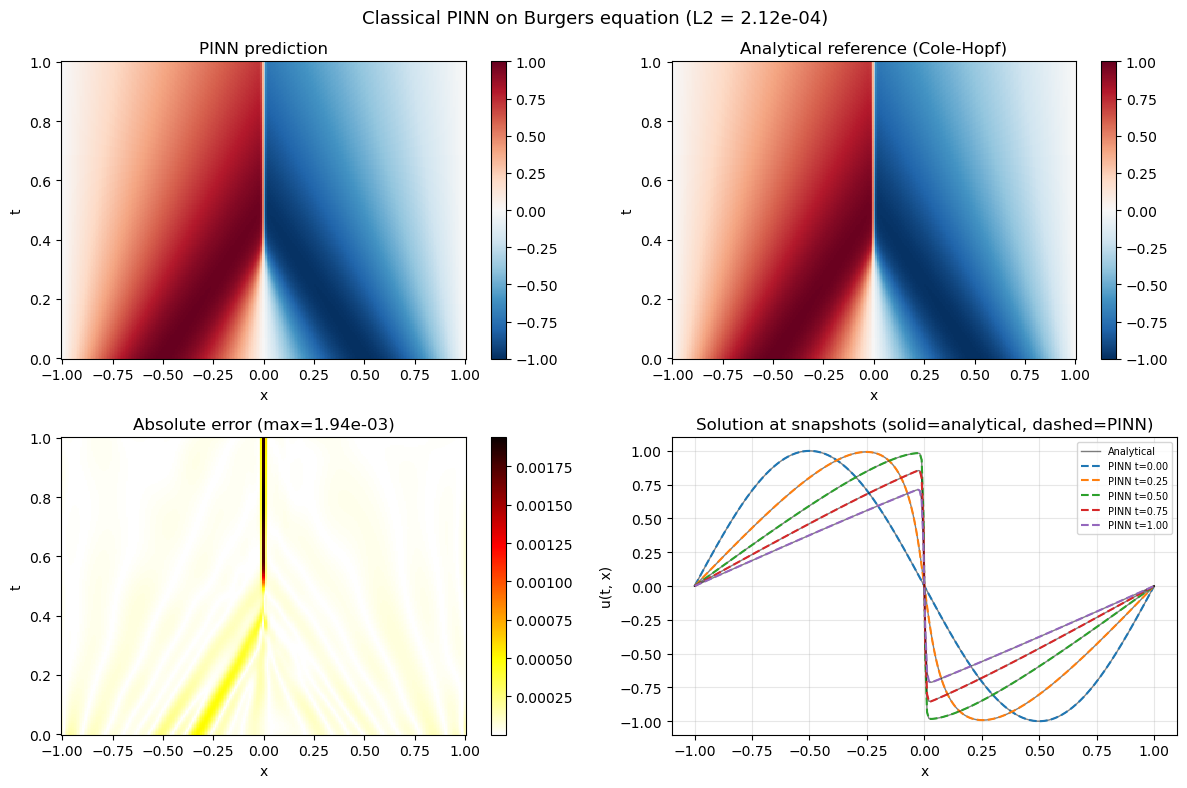

[OK] Figure saved


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

ax = axes[0, 0]
im = ax.pcolormesh(x_eval, t_eval, u_pred, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('PINN prediction')
plt.colorbar(im, ax=ax)

ax = axes[0, 1]
im = ax.pcolormesh(x_eval, t_eval, u_ref, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('Analytical reference (Cole-Hopf)')
plt.colorbar(im, ax=ax)

ax = axes[1, 0]
im = ax.pcolormesh(x_eval, t_eval, np.abs(u_pred_64 - u_ref), shading='auto', cmap='hot_r')
ax.set_xlabel('x'); ax.set_ylabel('t')
ax.set_title(f'Absolute error (max={np.max(np.abs(u_pred_64-u_ref)):.2e})')
plt.colorbar(im, ax=ax)

ax = axes[1, 1]
for t_snap in [0.0, 0.25, 0.5, 0.75, 1.0]:
    idx = np.argmin(np.abs(t_eval - t_snap))
    ax.plot(x_eval, u_ref[idx, :], 'k-', alpha=0.5, linewidth=1, label='Analytical' if t_snap == 0 else '')
    ax.plot(x_eval, u_pred[idx, :], '--', linewidth=1.5, label=f'PINN t={t_snap:.2f}')
ax.set_xlabel('x'); ax.set_ylabel('u(t, x)')
ax.set_title('Solution at snapshots (solid=analytical, dashed=PINN)')
ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

plt.suptitle(f"Classical PINN on Burgers equation (L2 = {l2_error:.2e})", fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_pinn_vs_reference.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Figure saved")

## 10. XAI Hook 1: Fourier Spectrum of Hidden-Layer Activations

Tanh layers at indices: [1, 3, 5, 7, 9, 11, 13, 15]
[OK] Activations shape: (512, 20)


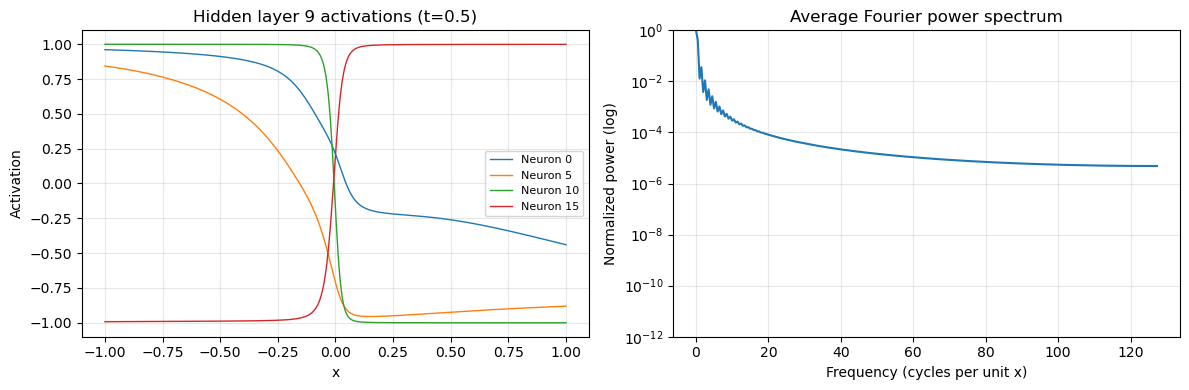

[OK] Fourier spectrum saved
     Dominant frequency: 0.00 cycles/unit


In [11]:
activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

tanh_layers = [i for i, m in enumerate(model.net) if isinstance(m, nn.Tanh)]
print(f"Tanh layers at indices: {tanh_layers}")

mid_idx = tanh_layers[len(tanh_layers) // 2]
handle = model.net[mid_idx].register_forward_hook(get_activation(f'layer_{mid_idx}'))

n_fourier = 512
x_fourier = np.linspace(X_MIN, X_MAX, n_fourier)
t_fourier = np.ones(n_fourier) * 0.5

with torch.no_grad():
    _ = model(torch.tensor(x_fourier, dtype=DTYPE).reshape(-1, 1),
              torch.tensor(t_fourier, dtype=DTYPE).reshape(-1, 1))

handle.remove()

act = activations[f'layer_{mid_idx}'].numpy()
print(f"[OK] Activations shape: {act.shape}")

fft_results = np.fft.fft(act, axis=0)
freqs = np.fft.fftfreq(n_fourier, d=(x_fourier[1] - x_fourier[0]))
power = np.abs(fft_results) ** 2
avg_power = np.mean(power, axis=1)
avg_power_norm = avg_power / np.max(avg_power)

n_pos = n_fourier // 2
freqs_pos = freqs[:n_pos]
power_pos = avg_power_norm[:n_pos]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for neuron_idx in [0, 5, 10, 15]:
    ax.plot(x_fourier, act[:, neuron_idx], linewidth=1, label=f'Neuron {neuron_idx}')
ax.set_xlabel('x'); ax.set_ylabel('Activation')
ax.set_title(f'Hidden layer {mid_idx} activations (t=0.5)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.semilogy(freqs_pos, power_pos, linewidth=1.5)
ax.set_xlabel('Frequency (cycles per unit x)')
ax.set_ylabel('Normalized power (log)')
ax.set_title('Average Fourier power spectrum')
ax.grid(True, alpha=0.3); ax.set_ylim([1e-12, 1])

plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_xai_fourier_spectrum.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] Fourier spectrum saved")
print(f"     Dominant frequency: {freqs_pos[np.argmax(power_pos)]:.2f} cycles/unit")

## 11. XAI Hook 2: Loss Landscape Visualization

Generating loss landscape (this takes ~30-60 sec)...
  Row 10/51 done
  Row 20/51 done
  Row 30/51 done
  Row 40/51 done
  Row 50/51 done
[OK] Loss landscape computed
     Min: 4.971890e-08, Max: 2.761410e+03


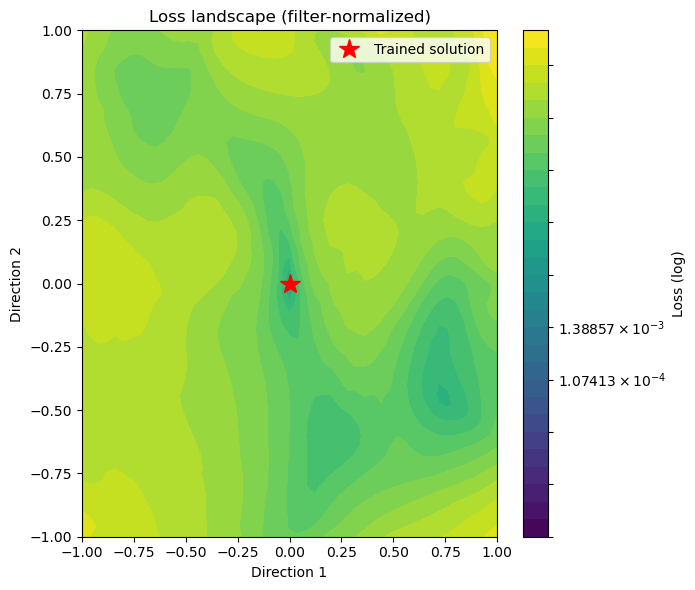

[OK] Loss landscape saved


In [12]:
print("Generating loss landscape (this takes ~30-60 sec)...")

trained_params = [p.detach().clone() for p in model.parameters()]

def get_random_direction(model):
    direction = []
    for param in model.parameters():
        d = torch.randn_like(param)
        norm = torch.norm(d)
        if norm > 0:
            d = d / norm
        d = d * torch.norm(param.detach())
        direction.append(d)
    return direction

dir1 = get_random_direction(model)
dir2 = get_random_direction(model)

grid_size = 51
alpha_range = np.linspace(-1, 1, grid_size)
beta_range = np.linspace(-1, 1, grid_size)
loss_grid = np.zeros((grid_size, grid_size))

model.eval()
with torch.enable_grad():
    for i, alpha in enumerate(alpha_range):
        for j, beta in enumerate(beta_range):
            for k, param in enumerate(model.parameters()):
                param.data = trained_params[k] + alpha * dir1[k] + beta * dir2[k]
            loss, _, _ = compute_loss(model, x_u, t_u, u_u, x_f, t_f)
            loss_grid[i, j] = loss.item()
        if (i + 1) % 10 == 0:
            print(f"  Row {i+1}/{grid_size} done")

for k, param in enumerate(model.parameters()):
    param.data = trained_params[k].clone()

print(f"[OK] Loss landscape computed")
print(f"     Min: {np.min(loss_grid):.6e}, Max: {np.max(loss_grid):.6e}")

fig, ax = plt.subplots(1, 1, figsize=(7, 6))
A, B = np.meshgrid(alpha_range, beta_range)
levels = np.logspace(np.log10(max(np.min(loss_grid), 1e-12)), np.log10(np.max(loss_grid)), 30)
cs = ax.contourf(A, B, loss_grid, levels=levels, cmap='viridis',
                 norm=plt.matplotlib.colors.LogNorm())
ax.plot(0, 0, 'r*', markersize=15, label='Trained solution')
ax.set_xlabel('Direction 1'); ax.set_ylabel('Direction 2')
ax.set_title('Loss landscape (filter-normalized)')
plt.colorbar(cs, ax=ax, label='Loss (log)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_xai_loss_landscape.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Loss landscape saved")

## 12. XAI Hook 3: Neuron Activation Histograms

Extracting activations from all hidden layers...


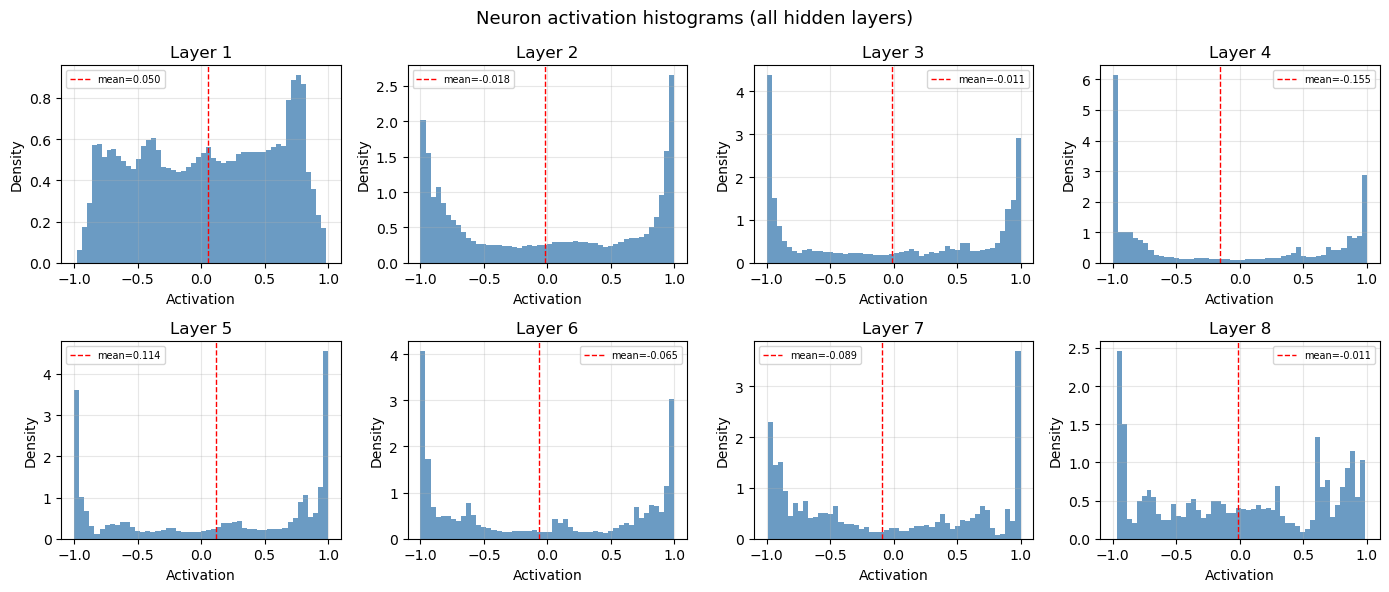

[OK] Neuron histograms saved (all 8 layers should now show data)


In [13]:
print("Extracting activations from all hidden layers...")

handles = []
for idx in tanh_layers:
    h = model.net[idx].register_forward_hook(get_activation(f'tanh_{idx}'))
    handles.append(h)

n_hist_x, n_hist_t = 100, 100
x_hist = np.linspace(X_MIN, X_MAX, n_hist_x)
t_hist = np.linspace(T_MIN, T_MAX, n_hist_t)
X_hist, T_hist = np.meshgrid(x_hist, t_hist)

with torch.no_grad():
    _ = model(torch.tensor(X_hist.flatten(), dtype=DTYPE).reshape(-1, 1),
              torch.tensor(T_hist.flatten(), dtype=DTYPE).reshape(-1, 1))

for h in handles:
    h.remove()

n_layers = len(tanh_layers)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for i, idx in enumerate(tanh_layers):
    ax = axes[i]
    # FIX #7: read from activations dict with correct key 'tanh_{idx}'
    act = activations.get(f'tanh_{idx}')
    if act is None:
        ax.set_title(f'Layer {i+1} (no data)')
        continue
    act_flat = act.numpy().flatten()
    ax.hist(act_flat, bins=50, density=True, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_xlabel('Activation'); ax.set_ylabel('Density')
    ax.set_title(f'Layer {i+1}')
    ax.set_xlim([-1.1, 1.1]); ax.grid(True, alpha=0.3)
    ax.axvline(np.mean(act_flat), color='red', linestyle='--', linewidth=1, label=f'mean={np.mean(act_flat):.3f}')
    ax.legend(fontsize=7)

plt.suptitle('Neuron activation histograms (all hidden layers)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_xai_neuron_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Neuron histograms saved (all 8 layers should now show data)")

## 13. XAI Hook 4: Gradient Saliency Maps 

Computing input gradients (saliency maps)...


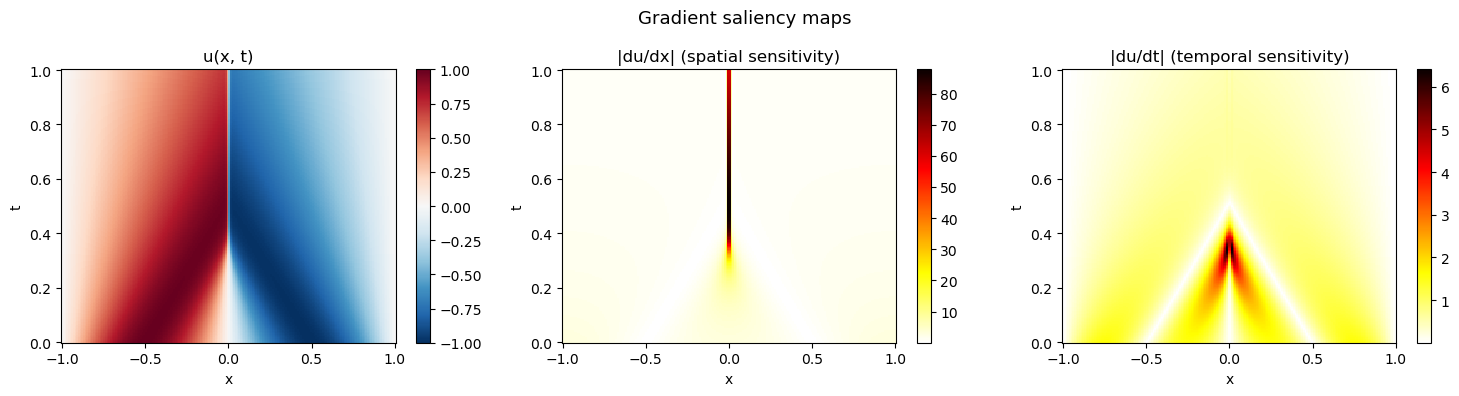

[OK] Saliency maps saved
     Max |du/dx| = 87.7714 (should peak at shock)
     Max |du/dt| = 6.4087


In [14]:
print("Computing input gradients (saliency maps)...")

n_sal = 200
x_sal = np.linspace(X_MIN, X_MAX, n_sal)
t_sal = np.linspace(T_MIN, T_MAX, n_sal)
X_sal, T_sal = np.meshgrid(x_sal, t_sal)

x_g = torch.tensor(X_sal.flatten(), dtype=DTYPE, device=device).reshape(-1, 1).requires_grad_(True)
t_g = torch.tensor(T_sal.flatten(), dtype=DTYPE, device=device).reshape(-1, 1).requires_grad_(True)
u_g = model(x_g, t_g)

# FIX #8: retain_graph=True on the first grad call so the second one doesn't crash
u_x_sal = torch.autograd.grad(u_g, x_g, torch.ones_like(u_g), create_graph=False, retain_graph=True)[0]
u_t_sal = torch.autograd.grad(u_g, t_g, torch.ones_like(u_g), create_graph=False)[0]

u_sal = u_g.detach().numpy().reshape(n_sal, n_sal)
u_x_sal = u_x_sal.detach().numpy().reshape(n_sal, n_sal)
u_t_sal = u_t_sal.detach().numpy().reshape(n_sal, n_sal)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
im = ax.pcolormesh(x_sal, t_sal, u_sal, shading='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('u(x, t)')
plt.colorbar(im, ax=ax)

ax = axes[1]
im = ax.pcolormesh(x_sal, t_sal, np.abs(u_x_sal), shading='auto', cmap='hot_r')
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('|du/dx| (spatial sensitivity)')
plt.colorbar(im, ax=ax)

ax = axes[2]
im = ax.pcolormesh(x_sal, t_sal, np.abs(u_t_sal), shading='auto', cmap='hot_r')
ax.set_xlabel('x'); ax.set_ylabel('t'); ax.set_title('|du/dt| (temporal sensitivity)')
plt.colorbar(im, ax=ax)

plt.suptitle('Gradient saliency maps', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DIRS['figures'], 'phase1_xai_saliency.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] Saliency maps saved")
print(f"     Max |du/dx| = {np.max(np.abs(u_x_sal)):.4f} (should peak at shock)")
print(f"     Max |du/dt| = {np.max(np.abs(u_t_sal)):.4f}")

## 14. Save Results to folder

[OK] Model saved: /home/roland/WISER/results/phase1_burgers_20260714_171438/classical_pinn.pt
[OK] Metrics saved


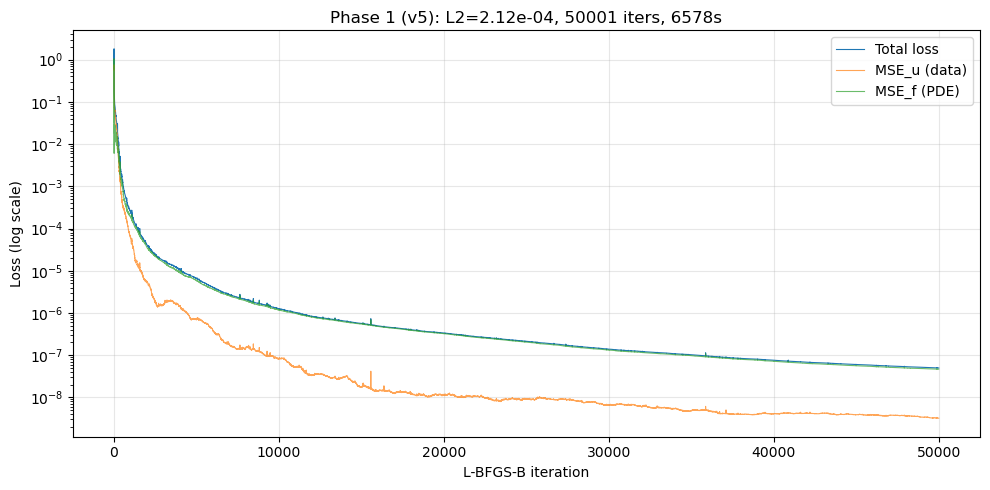


SUMMARY FOR SUNDAY SYNC REPORT
Phase 1 (Classical Baseline, Corrected v5) completed: 20260714_171438
  PDE: 1D viscous Burgers (nu = 0.01/pi)
  Architecture: 8 hidden x 20 neurons, tanh, 3021 params
  Optimizer: scipy L-BFGS-B (Raissi's exact params)
    maxiter=50000, maxcor=50, maxls=50, ftol=machine_eps
  Training: 50001 iters in 6577.9s (109.6 min)
  Reference: Analytical Cole-Hopf (float64)
  Collocation: LHS (seed=42)
  Init: xavier_uniform_ (Glorot uniform)
  Relative L2 error: 2.121062e-04  (target: 6.7e-4)
  PDE residual (mean): 1.775374e-04
  PDE residual (max):  3.186380e-02
  Generalization error: 3.204603e-04
  Final loss: 4.971890e-08
  Status: verified


In [15]:
timestamp = time.strftime('%Y%m%d_%H%M%S')
results_dir = os.path.join(DIRS['results'], f'phase1_burgers_{timestamp}')
os.makedirs(results_dir, exist_ok=True)

model_path = os.path.join(results_dir, 'classical_pinn.pt')
torch.save({'model_state_dict': model.state_dict(), 'n_params': n_params}, model_path)
print(f"[OK] Model saved: {model_path}")

np.save(os.path.join(results_dir, 'loss_history.npy'), np.array(loss_history))
np.save(os.path.join(results_dir, 'mse_u_history.npy'), np.array(mse_u_history))
np.save(os.path.join(results_dir, 'mse_f_history.npy'), np.array(mse_f_history))

metrics = {
    'timestamp': timestamp,
    'authors': ['Ounomborbitibou Djabon', 'Hounkpè Mawouliklimi Roland'],
    'phase': '1',
    'deliverable': 'Classical Baseline - Burgers equation (Corrected v6 - float64)',
    'configuration': {
        'pde': '1D viscous Burgers', 'nu': float(NU),
        'architecture': '8 hidden layers x 20 neurons, tanh',
        'n_params': n_params, 'n_data_points': N_U,
        'n_collocation_points': N_F,
        'collocation_sampling': 'Latin Hypercube (scipy.stats.qmc.LatinHypercube)',
        'optimizer': 'scipy L-BFGS-B (Raissi\'s exact optimizer)',
        'optimizer_config': {
            'method': 'L-BFGS-B',
            'maxiter': 50000, 'maxfun': 50000,
            'maxcor': 50, 'maxls': 50,
            'ftol': float(1.0 * np.finfo(float).eps),
            'gtol': float(1.0 * np.finfo(float).eps),
        },
        'init': 'xavier_uniform_ (Glorot uniform)',
        'reference': 'Analytical Cole-Hopf (float64)',
        'seed': SEED,
    },
    'results': {
        'relative_l2_error': float(l2_error),
        'pde_residual_mean': float(pde_mean),
        'pde_residual_max': float(pde_max),
        'generalization_error': float(gen_error),
        'training_time_sec': float(train_time),
        'total_iterations': iteration[0],
        'final_loss': float(final_loss),
        'optimizer_success': bool(result.success),
    },
    'target': {
        'raissi_l2_error': 6.7e-4,
        'status': 'verified' if l2_error < 1e-3 else ('acceptable' if l2_error < 1e-2 else 'needs_work'),
    },
    'fixes_applied': [
        '1. Analytical Cole-Hopf reference (was: numerical method-of-lines)',
        '2. Latin Hypercube Sampling for collocation (was: np.random.uniform)',
        '3. scipy L-BFGS-B with Raissi exact params (was: PyTorch LBFGS that stalls)',
        '4. xavier_uniform_ init (was: xavier_normal_)',
        '5. No interpolation — analytical at exact grid (was: linear interp)',
        '6. float64 for reference + L2 comparison (was: float32)',
        '7. Neuron histogram bug fixed (all 8 layers now show data)',
        '8. Saliency retain_graph=True fix (was: RuntimeError crash)',
    ],
}

with open(os.path.join(results_dir, 'metrics.json'), 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"[OK] Metrics saved")

# Loss curve
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(loss_history, linewidth=0.8, label='Total loss')
ax.plot(mse_u_history, linewidth=0.8, alpha=0.7, label='MSE_u (data)')
ax.plot(mse_f_history, linewidth=0.8, alpha=0.7, label='MSE_f (PDE)')
ax.set_xlabel('L-BFGS-B iteration'); ax.set_ylabel('Loss (log scale)')
ax.set_yscale('log')
ax.set_title(f"Phase 1 (v5): L2={l2_error:.2e}, {iteration[0]} iters, {train_time:.0f}s")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(results_dir, 'loss_curve.png'), dpi=150)
plt.show()

print()
print("=" * 60)
print("SUMMARY FOR SUNDAY SYNC REPORT")
print("=" * 60)
print(f"Phase 1 (Classical Baseline, Corrected v5) completed: {timestamp}")
print(f"  PDE: 1D viscous Burgers (nu = 0.01/pi)")
print(f"  Architecture: 8 hidden x 20 neurons, tanh, 3021 params")
print(f"  Optimizer: scipy L-BFGS-B (Raissi's exact params)")
print(f"    maxiter=50000, maxcor=50, maxls=50, ftol=machine_eps")
print(f"  Training: {iteration[0]} iters in {train_time:.1f}s ({train_time/60:.1f} min)")
print(f"  Reference: Analytical Cole-Hopf (float64)")
print(f"  Collocation: LHS (seed={SEED})")
print(f"  Init: xavier_uniform_ (Glorot uniform)")
print(f"  Relative L2 error: {l2_error:.6e}  (target: 6.7e-4)")
print(f"  PDE residual (mean): {pde_mean:.6e}")
print(f"  PDE residual (max):  {pde_max:.6e}")
print(f"  Generalization error: {gen_error:.6e}")
print(f"  Final loss: {final_loss:.6e}")
print(f"  Status: {metrics['target']['status']}")